# Replication Notebook — TCN-attention-HAR (WISDM-first)


## Paper Facts and Code Availability
- Paper DOI: https://doi.org/10.1038/s41598-024-57912-3
- Official repo: none declared by paper
- Non-authoritative reference: https://github.com/zhuwei55555/TCN-attention-HAR

## WISDM Adaptation
- Active config: `configs/papers/tcn_attention_wisdm.yaml`
- This notebook runs WISDM-first adaptation while preserving paper architecture intent.


## Notebook Contract
- Runtime / dependency guard
- Paper facts + code availability
- WISDM adaptation section
- FP32 training/eval on `random_stratified` + `user_holdout`
- PTQ INT8 + QAT INT8 exports
- Strict deploy-gate summary (`full_integer_io`, `tflm_compatible`, unsupported ops)
- Per-paper CSV/MD + master results append


## Compression Scope Note
- KD-related methodology from papers is documented for reproducibility context only.
- Notebook execution enforces PTQ/QAT compression flow only (`experiment.compression_focus=ptq_qat_only`).
- This notebook uses a Conv2D-equivalent architecture for QAT compatibility; Conv1D paper operators are preserved semantically via `(k)->(k,1)` mapping.


In [1]:
from pathlib import Path
import sys
import os
import json
import importlib
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

# Optional safeguard: disable GPU if kernel is unstable on CUDA runtime.
USE_GPU = True
if not USE_GPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Ensure repo root is importable when launched from different working directories.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    for parent in [REPO_ROOT, *REPO_ROOT.parents]:
        if (parent / "src").exists():
            REPO_ROOT = parent
            break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

required_modules = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "IPython": "ipython",
    "yaml": "PyYAML",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
    "tensorflow_model_optimization": "tensorflow-model-optimization",
}
missing = [
    f"{mod} (pip package: {pkg})"
    for mod, pkg in required_modules.items()
    if importlib.util.find_spec(mod) is None
]
if missing:
    missing_text = "\n- ".join(missing)
    raise ModuleNotFoundError(
        "Missing required notebook dependencies:\n- "
        + missing_text
        + "\n\nActivate tinymlproj and install dependencies:\n"
        + "conda activate tinymlproj && conda env update -n tinymlproj -f environment.yml --prune"
    )

import tensorflow as tf
print("TF version:", tf.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))

AUTO_RELOAD_PROJECT_MODULES = True
if AUTO_RELOAD_PROJECT_MODULES:
    for _mod_name in (
        "src.models.xtinyhar_student_tf",
        "src.models.repmobile_folded_tf",
        "src.models.tcn_attention_har_tf",
        "src.models.daghero_cnn_searchspace_tf",
        "src.models.tcn_inception_tf",
        "src.models.serialization",
        "src.eval.evaluate_model",
        "src.quant.ptq_full_int8",
        "src.quant.qat_train",
        "src.run_paper_experiment",
    ):
        if _mod_name in sys.modules:
            importlib.reload(sys.modules[_mod_name])

import src.run_paper_experiment as _run_mod
run_paper_experiment = _run_mod.run_paper_experiment

from src.utils.config import load_yaml
from src.utils.device_runtime import runtime_device_report
from src.eval.evaluate_model import evaluate_model_for_protocol
from src.utils.artifacts import model_ckpt_path, split_npz_path

if "load_checkpoint_model" not in evaluate_model_for_protocol.__code__.co_names:
    raise RuntimeError(
        "Stale evaluate_model module detected (safe loader missing). "
        "Restart kernel and rerun from the first cell."
    )

RUN_MODE = "sanity_check"  # switch to "full_run" for final CPU-only benchmark runs
CONFIG_PATH = REPO_ROOT / 'configs/papers/tcn_attention_wisdm.yaml'
assert CONFIG_PATH.exists(), f"Missing config: {CONFIG_PATH}"
cfg = load_yaml(CONFIG_PATH)
cfg.setdefault("runtime", {})["run_mode"] = RUN_MODE
cfg.setdefault("experiment", {})["compression_focus"] = "ptq_qat_only"
runtime = runtime_device_report(cfg)

print("repo_root:", REPO_ROOT)
print("paper_slug:", cfg.get("experiment", {}).get("paper_slug"))
print("model_variant:", cfg.get("experiment", {}).get("model_variant"))
is_conv2d_variant = str(cfg.get("experiment", {}).get("model_variant", "")).endswith("_conv2d")
print("conv2d_qat_safe_variant:", is_conv2d_variant)
print("[NOTE] Conv1D paper ops are executed via Conv2D-equivalent mapping (k)->(k,1) for QAT compatibility.")
if not is_conv2d_variant:
    print("[WARN] Active model_variant is not *_conv2d; QAT may fail on Conv1D/SeparableConv1D in tfmot 0.8.")
print("window_size:", cfg.get("paper_protocol", {}).get("wisdm_window_override"))
print("run_mode:", runtime["run_mode"])
print("detected_gpus:", runtime["gpus"])
print("stage_device_map:", runtime["resolved_stage_devices"])
print("[NOTE] Auto-reload is ON to prevent stale module paths in notebook runtime.")


2026-03-03 02:38:28.082278: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-03 02:38:28.082389: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-03 02:38:28.083982: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-03 02:38:28.215334: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.14.1
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-03-03 02:38:30.787625: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-03 02:38:30.810109: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-03 02:38:30.810163: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.


repo_root: /home/dellio/github/har-mcu
paper_slug: tcn_attention_har
model_variant: tcn_attention_har_teacher_conv2d
conv2d_qat_safe_variant: True
[NOTE] Conv1D paper ops are executed via Conv2D-equivalent mapping (k)->(k,1) for QAT compatibility.
window_size: 200
run_mode: sanity_check
detected_gpus: ['/physical_device:GPU:0']
stage_device_map: {'train': 'gpu', 'eval_fp32': 'gpu', 'ptq': 'gpu', 'eval_ptq': 'gpu', 'qat': 'cpu', 'eval_qat': 'cpu'}
[NOTE] Auto-reload is ON to prevent stale module paths in notebook runtime.


In [2]:
# Run FP32 + PTQ + QAT + standardized reporting
out = run_paper_experiment(cfg)
out


2026-03-03 02:38:31.459509: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-03 02:38:31.459596: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-03 02:38:31.459634: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-03 02:38:31.648408: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-03 02:38:31.648588: I tensorflow/compile

Epoch 1/100


2026-03-03 02:38:36.552880: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape ingradient_tape/tcn_attention_har_teacher_conv2d/tcn_k3_d1_drop1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-03 02:38:37.108313: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-03-03 02:38:38.502846: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7654b65b7d00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-03 02:38:38.502894: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-03-03 02:38:38.512729: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-03 02:38:38.614308: I ./tensorf

84/84 - 15s - loss: 0.7876 - accuracy: 0.7295 - val_loss: 0.4196 - val_accuracy: 0.8579 - lr: 5.0000e-04 - 15s/epoch - 174ms/step
Epoch 2/100
84/84 - 5s - loss: 0.2558 - accuracy: 0.9089 - val_loss: 0.1792 - val_accuracy: 0.9461 - lr: 5.0000e-04 - 5s/epoch - 57ms/step
Epoch 3/100
84/84 - 5s - loss: 0.1495 - accuracy: 0.9506 - val_loss: 0.0933 - val_accuracy: 0.9708 - lr: 5.0000e-04 - 5s/epoch - 57ms/step
Epoch 4/100
84/84 - 5s - loss: 0.0958 - accuracy: 0.9703 - val_loss: 0.0728 - val_accuracy: 0.9738 - lr: 5.0000e-04 - 5s/epoch - 59ms/step
Epoch 5/100
84/84 - 5s - loss: 0.0668 - accuracy: 0.9804 - val_loss: 0.0434 - val_accuracy: 0.9798 - lr: 5.0000e-04 - 5s/epoch - 56ms/step
Epoch 6/100
84/84 - 5s - loss: 0.0579 - accuracy: 0.9802 - val_loss: 0.0411 - val_accuracy: 0.9873 - lr: 5.0000e-04 - 5s/epoch - 59ms/step
Epoch 7/100
84/84 - 5s - loss: 0.0447 - accuracy: 0.9865 - val_loss: 0.0492 - val_accuracy: 0.9850 - lr: 5.0000e-04 - 5s/epoch - 55ms/step
Epoch 8/100
84/84 - 5s - loss: 0.043

INFO:tensorflow:Assets written to: /tmp/tmp7umfbyjt/assets
/home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-03 02:42:12.512201: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 02:42:12.512258: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-03 02:42:12.515578: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7umfbyjt
2026-03-03 02:42:12.528290: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 02:42:12.528331: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7umfbyjt
2026-03-03 02:42:12.556934: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 opt

...

Epoch 1/10


2026-03-03 02:54:55.709046: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


83/83 - 58s - loss: 0.0780 - accuracy: 0.9833 - val_loss: 0.4802 - val_accuracy: 0.8708 - 58s/epoch - 698ms/step
Epoch 2/10
83/83 - 52s - loss: 0.0387 - accuracy: 0.9932 - val_loss: 0.5781 - val_accuracy: 0.8593 - 52s/epoch - 629ms/step
Epoch 3/10
83/83 - 50s - loss: 0.0474 - accuracy: 0.9873 - val_loss: 0.6080 - val_accuracy: 0.8677 - 50s/epoch - 607ms/step
Epoch 4/10
83/83 - 51s - loss: 0.0416 - accuracy: 0.9901 - val_loss: 0.6932 - val_accuracy: 0.8662 - 51s/epoch - 614ms/step
Epoch 5/10
83/83 - 50s - loss: 0.0329 - accuracy: 0.9924 - val_loss: 0.7264 - val_accuracy: 0.8601 - 50s/epoch - 608ms/step
Epoch 6/10
83/83 - 50s - loss: 0.0311 - accuracy: 0.9928 - val_loss: 0.6947 - val_accuracy: 0.8677 - 50s/epoch - 607ms/step
Epoch 7/10
83/83 - 51s - loss: 0.0259 - accuracy: 0.9930 - val_loss: 0.8326 - val_accuracy: 0.8440 - 51s/epoch - 610ms/step
Epoch 8/10
83/83 - 51s - loss: 0.0220 - accuracy: 0.9951 - val_loss: 0.8689 - val_accuracy: 0.8341 - 51s/epoch - 611ms/step
Epoch 9/10
83/83 - 

INFO:tensorflow:Assets written to: /tmp/tmp0x75t0ny/assets
/home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-03 03:03:38.012206: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 03:03:38.012259: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-03 03:03:38.015366: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp0x75t0ny
2026-03-03 03:03:38.034176: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 03:03:38.034212: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp0x75t0ny
2026-03-03 03:03:38.108252: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

{'paper_slug': 'tcn_attention_har',
 'rows': [{'paper_slug': 'tcn_attention_har',
   'protocol': 'random_stratified',
   'variant': 'tcn_attention_har_teacher_conv2d',
   'run_id': 'wisdm_r0',
   'window_size': 200,
   'seed': 42,
   'compression_focus': 'ptq_qat_only',
   'run_mode': 'sanity_check',
   'train_device': 'gpu',
   'eval_fp32_device': 'gpu',
   'ptq_device': 'gpu',
   'eval_ptq_device': 'gpu',
   'qat_device': 'cpu',
   'eval_qat_device': 'cpu',
   'fp32_training_time_sec': 207.1802610379964,
   'qat_training_time_sec': 515.1469900859956,
   'accuracy': 0.9951397326852977,
   'macro_f1': 0.9903443753213494,
   'ptq_status': 'failed',
   'qat_status': 'failed',
   'ptq_accuracy': 0.9948359659781288,
   'ptq_macro_f1': 0.9900820236115063,
   'qat_accuracy': 0.9960510328068044,
   'qat_macro_f1': 0.9929304878846664,
   'ptq_model_size_kb': 623.9921875,
   'qat_model_size_kb': 631.390625,
   'model_size_kb': 623.9921875,
   'ptq_inference_latency_ms_median': 11.63788049598224

,paper_slug,protocol,variant,run_id,window_size,seed,compression_focus,run_mode,train_device,eval_fp32_device,...,deploy_gate,paper_target_score,delta_vs_paper,notes_assumptions,fp32_metrics_json,ptq_metrics_json,qat_metrics_json,ptq_report_json,qat_report_json,run_artifact_json
0,tcn_attention_har,random_stratified,tcn_attention_har_teacher_conv2d,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,"{'ptq': {'status': 'failed', 'full_integer_io'...",0.9903,0.004840,None,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...
1,tcn_attention_har,user_holdout,tcn_attention_har_teacher_conv2d,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,"{'ptq': {'status': 'failed', 'full_integer_io'...",0.9903,-0.129596,None,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...


/tmp/ipykernel_11133/2087302422.py:95: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  comp_df.style.format(


,pipeline,protocol,model,accuracy,macro_f1,model_size_kb,training_time_sec,inference_latency_ms_median,inference_latency_ms_p95,acc_delta_vs_target
0,paper target,—,baseline float,0.9903,—,—,—,—,—,—
1,paper target,—,PTQ int8,—,—,—,—,—,—,—
2,paper target,—,QAT int8,—,—,—,—,—,—,—
3,WISDM replication,random_stratified,baseline float,0.9951,0.9903,—,207.18s,—,—,+0.0048
4,WISDM replication,random_stratified,PTQ int8,0.9948,0.9901,623.99,—,11.638ms,12.103ms,—
5,WISDM replication,random_stratified,QAT int8,0.9961,0.9929,631.39,515.15s,11.380ms,13.508ms,—
6,WISDM replication,user_holdout,baseline float,0.8607,0.7936,—,66.47s,—,—,-0.1296
7,WISDM replication,user_holdout,PTQ int8,0.8645,0.7985,623.99,—,11.328ms,11.872ms,—
8,WISDM replication,user_holdout,QAT int8,0.8718,0.8207,631.39,514.82s,11.950ms,12.351ms,—


Note: Paper-target QAT may be unavailable in source papers; QAT rows here are replication extensions where target is N/A.


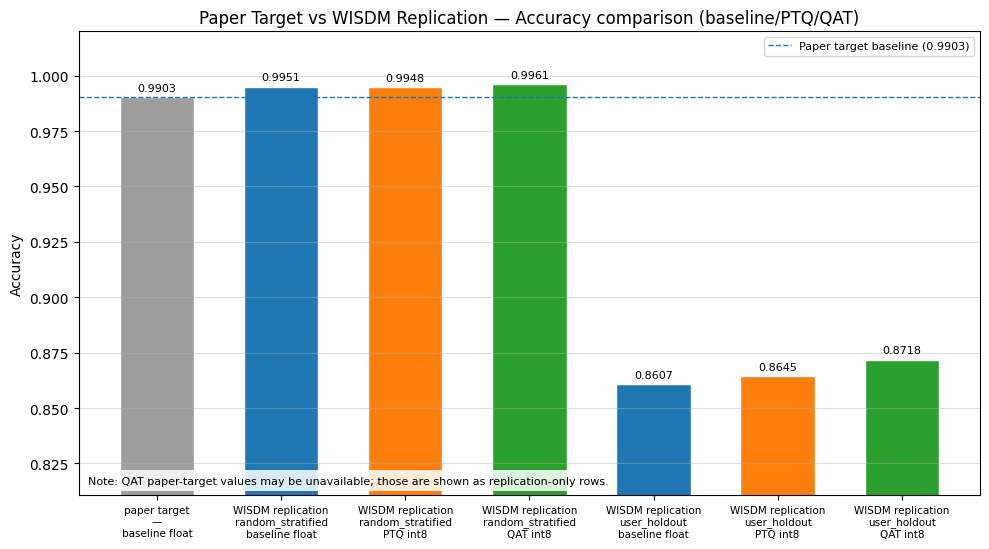

,pipeline,protocol,model,model_size_kb
0,WISDM replication,random_stratified,PTQ int8,623.99 KB
1,WISDM replication,random_stratified,QAT int8,631.39 KB
2,WISDM replication,user_holdout,PTQ int8,623.99 KB
3,WISDM replication,user_holdout,QAT int8,631.39 KB


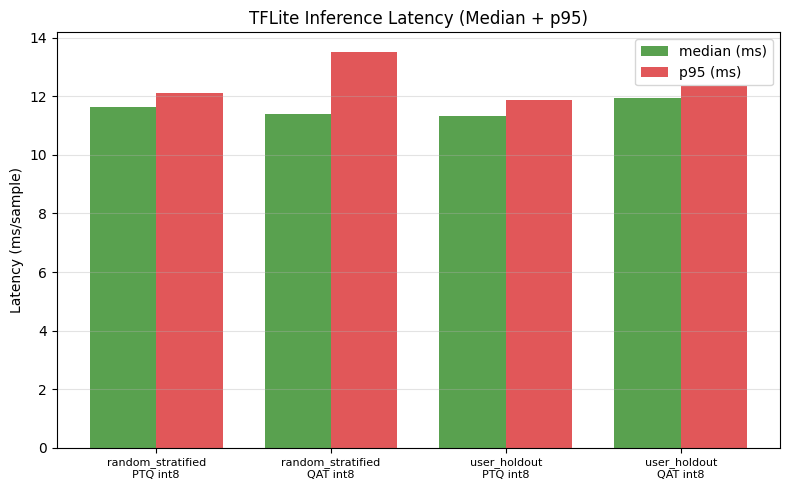


Reproducibility drift — WISDM replication (repeat evaluation on saved checkpoint):


/tmp/ipykernel_11133/2087302422.py:272: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  repro_df[["protocol", "split_hash", "baseline_acc_first", "baseline_acc_repeat", "abs_drift", "status"]]


,protocol,split_hash,baseline_acc_first,baseline_acc_repeat,abs_drift,status
0,random_stratified,68c9e31789bca103,0.9951,0.9951,0.00e+00,PASS
1,user_holdout,2498bff9ddcfc589,0.8607,0.8607,0.00e+00,PASS


### Protocol: `random_stratified`

**FP32 training curve**

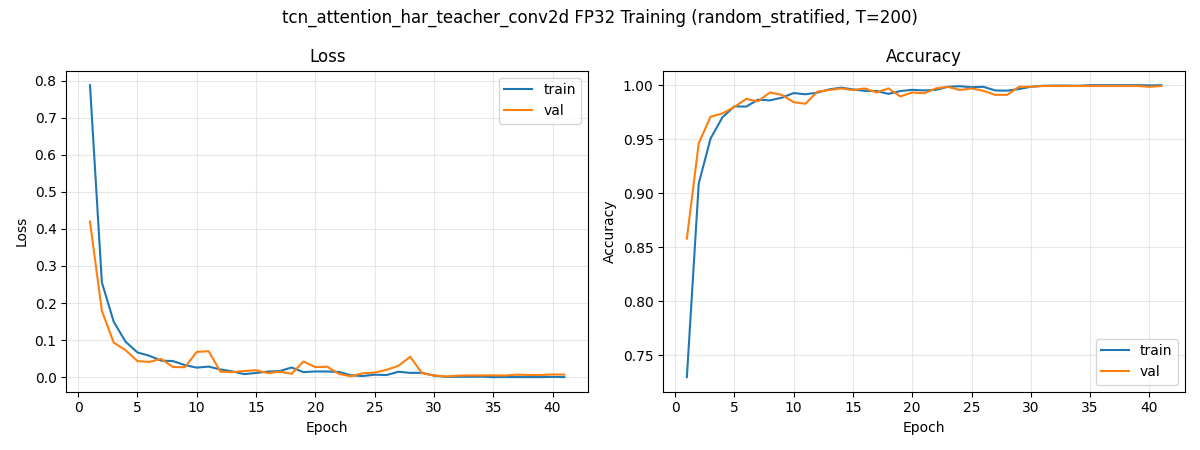

**QAT training curve**

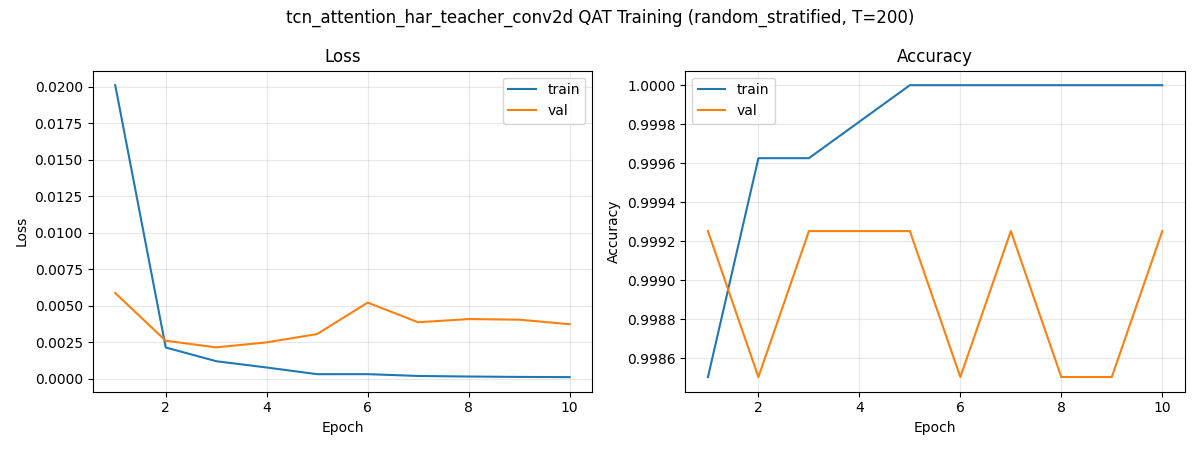

**FP32 confusion**

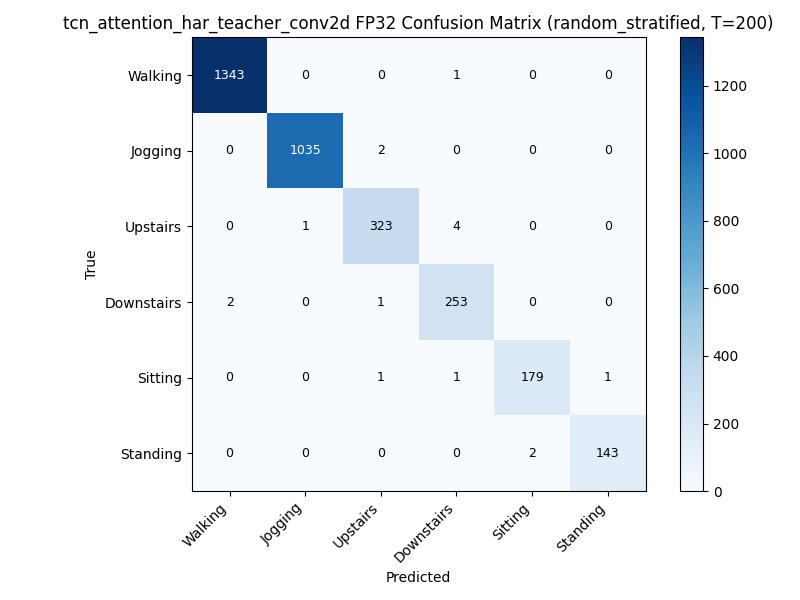

**PTQ confusion**

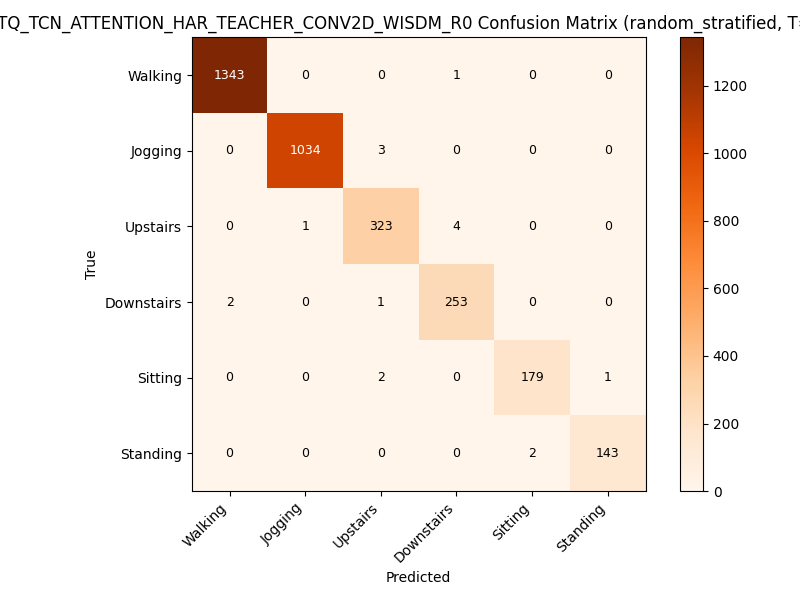

**QAT confusion**

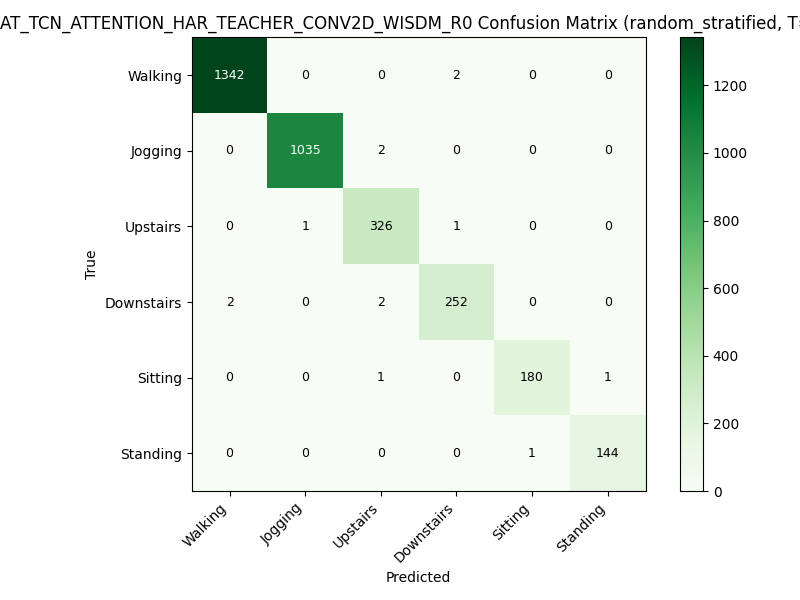

### Protocol: `user_holdout`

**FP32 training curve**

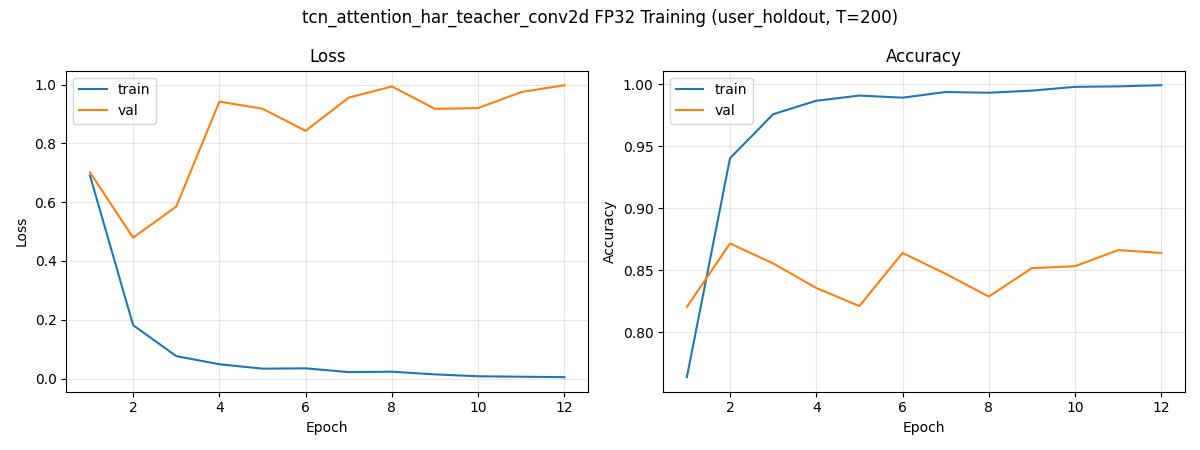

**QAT training curve**

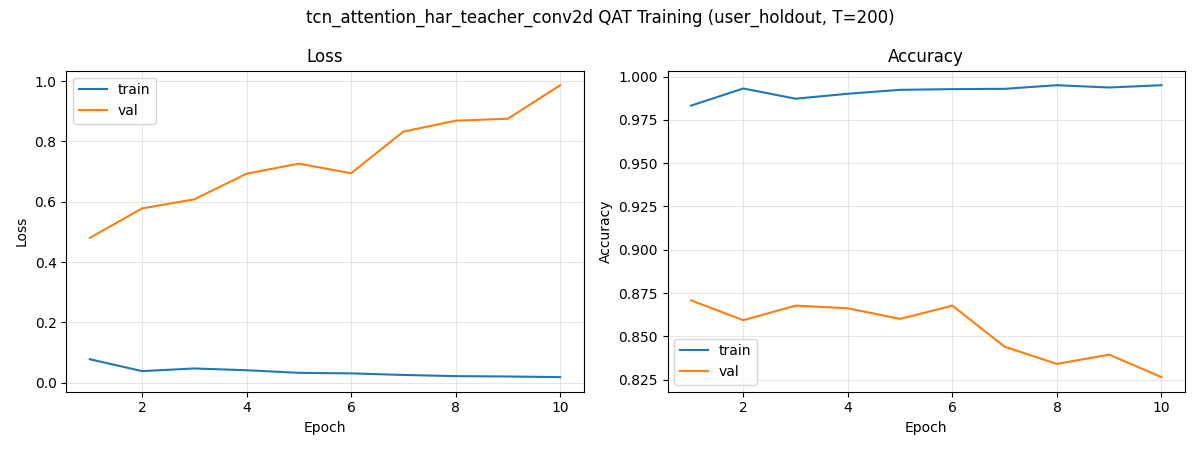

**FP32 confusion**

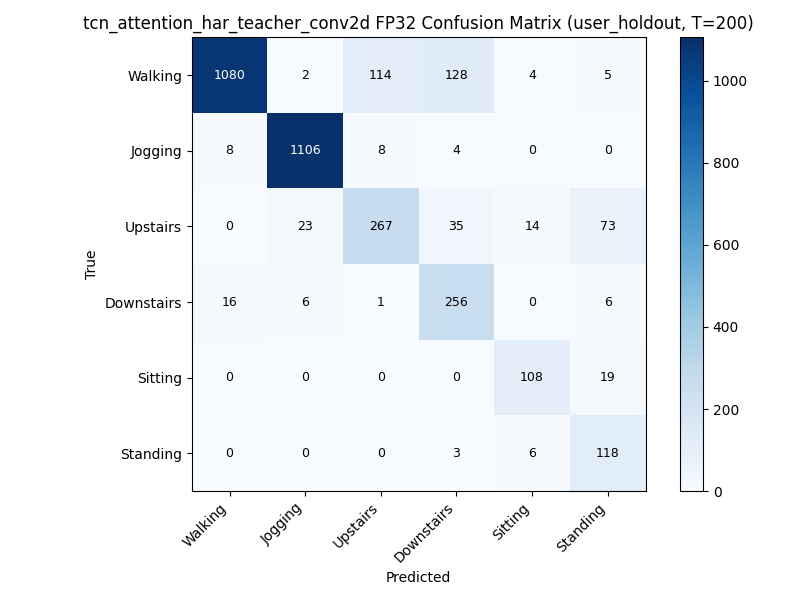

**PTQ confusion**

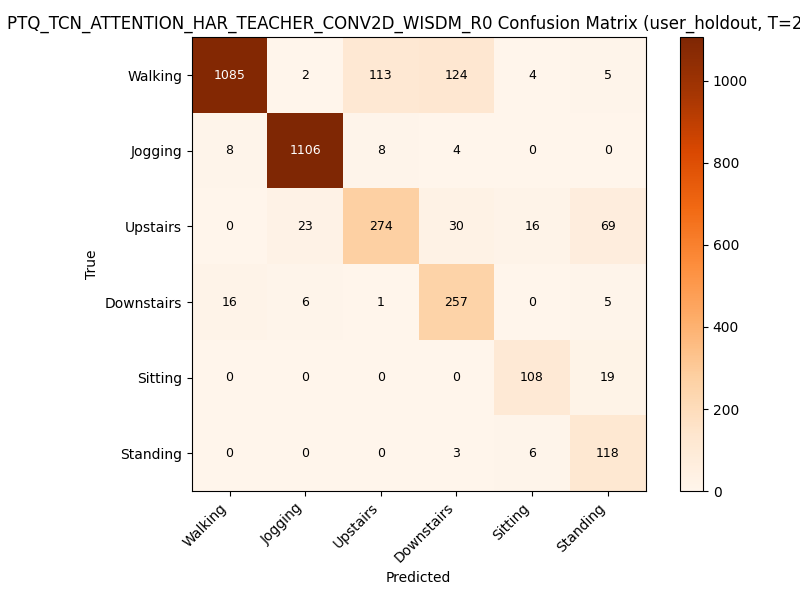

**QAT confusion**

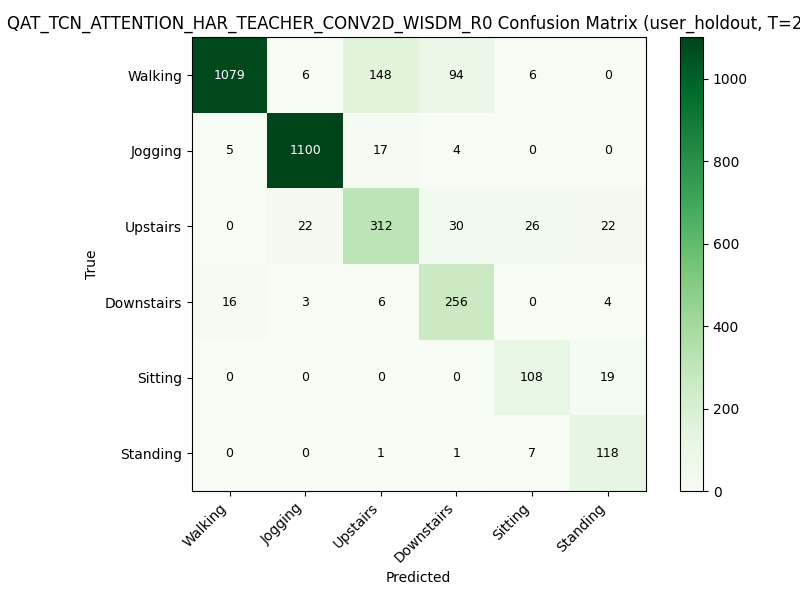

### Classification Report Snippets — `random_stratified`

FP32: macro_f1=0.9903443753213494, weighted_f1=0.9951418895014132
PTQ: macro_f1=0.9900820236115063, weighted_f1=0.9948391511390998
QAT: macro_f1=0.9929304878846664, weighted_f1=0.996052317161815


### Classification Report Snippets — `user_holdout`

FP32: macro_f1=0.7936474808556794, weighted_f1=0.8661897757040733
PTQ: macro_f1=0.7985137188882564, weighted_f1=0.8696300362052499
QAT: macro_f1=0.8207396670330422, weighted_f1=0.8762707817768035


## Saved Comparison CSV Snapshot

,pipeline,protocol,model,accuracy,macro_f1,model_size_kb,training_time_sec,inference_latency_ms_median,inference_latency_ms_p95,status,paper_target_accuracy,acc_delta_vs_target
0,WISDM replication,random_stratified,baseline float,0.995140,0.990344,NaN,207.180261,NaN,NaN,ok,0.9903,0.004840
1,WISDM replication,random_stratified,PTQ int8,0.994836,0.990082,623.992188,NaN,11.637880,12.102539,failed,NaN,NaN
2,WISDM replication,random_stratified,QAT int8,0.996051,0.992930,631.390625,515.146990,11.380064,13.507993,failed,NaN,NaN
3,WISDM replication,user_holdout,baseline float,0.860704,0.793647,NaN,66.468905,NaN,NaN,ok,0.9903,-0.129596
4,WISDM replication,user_holdout,PTQ int8,0.864516,0.798514,623.992188,NaN,11.328067,11.871704,failed,NaN,NaN
5,WISDM replication,user_holdout,QAT int8,0.871848,0.820740,631.390625,514.819863,11.950079,12.350502,failed,NaN,NaN
6,paper target,—,baseline float,0.990300,NaN,NaN,NaN,NaN,NaN,reference,0.9903,NaN
7,paper target,—,PTQ int8,NaN,NaN,NaN,NaN,NaN,NaN,reference,NaN,NaN
8,paper target,—,QAT int8,NaN,NaN,NaN,NaN,NaN,NaN,reference,NaN,NaN


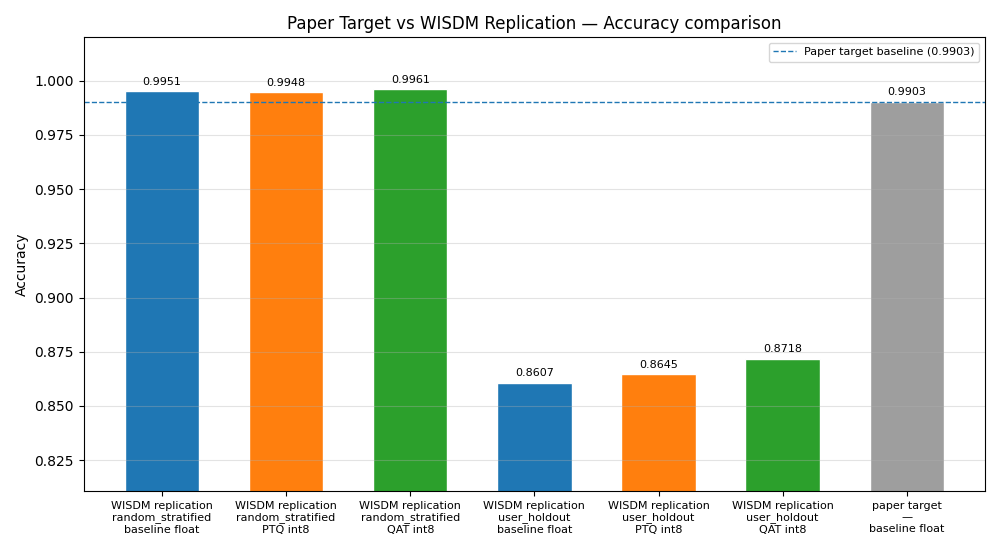

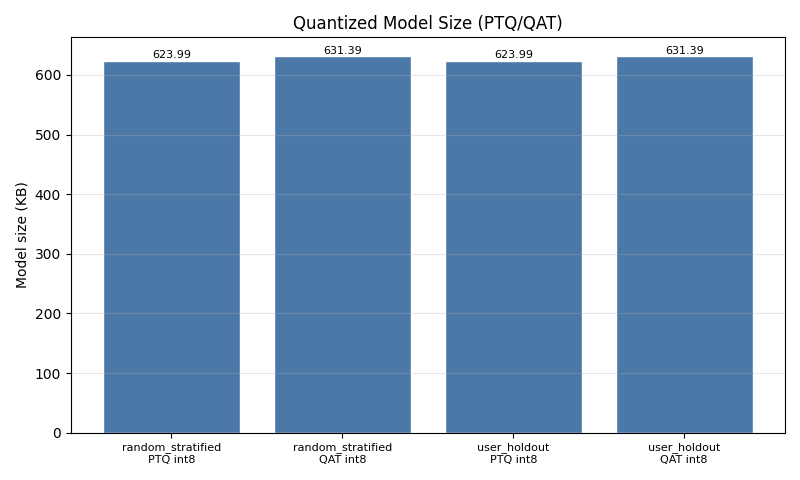

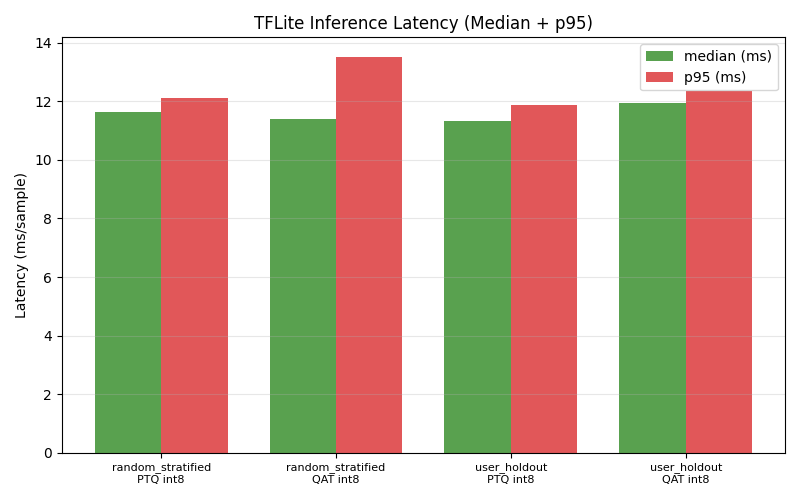

## Master Results Snapshot

,paper_slug,protocol,variant,run_id,window_size,seed,compression_focus,run_mode,train_device,eval_fp32_device,...,deploy_gate,paper_target_score,delta_vs_paper,notes_assumptions,fp32_metrics_json,ptq_metrics_json,qat_metrics_json,ptq_report_json,qat_report_json,run_artifact_json
8,tcn_attention_har,random_stratified,tcn_attention_har_teacher_conv2d,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,"{'ptq': {'status': 'failed', 'full_integer_io'...",0.9903,0.004840,NaN,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...
9,tcn_attention_har,user_holdout,tcn_attention_har_teacher_conv2d,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,"{'ptq': {'status': 'failed', 'full_integer_io'...",0.9903,-0.129596,NaN,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...,/home/dellio/github/har-mcu/reports/tcn_attent...


Saved outputs root: /home/dellio/github/har-mcu/reports/tcn_attention_har


In [3]:
# Run-level summary table
rows_df = pd.DataFrame(out["rows"])
display(rows_df)

# Build DeepConvLSTM-style paper-target vs WISDM replication rows
paper_targets = cfg.get("experiment", {}).get("paper_targets", {}) or {}
target_by_model = {
    "baseline float": paper_targets.get("fp32_accuracy"),
    "PTQ int8": paper_targets.get("ptq_accuracy"),
    "QAT int8": paper_targets.get("qat_accuracy"),
}

_comp_rows = []
for _model in ["baseline float", "PTQ int8", "QAT int8"]:
    _comp_rows.append(
        {
            "pipeline": "paper target",
            "protocol": "—",
            "model": _model,
            "accuracy": target_by_model.get(_model),
            "macro_f1": None,
            "model_size_kb": None,
            "training_time_sec": None,
            "inference_latency_ms_median": None,
            "inference_latency_ms_p95": None,
            "acc_delta_vs_target": None,
        }
    )

for _r in out["rows"]:
    _proto = _r.get("protocol")
    _fp32_target = target_by_model.get("baseline float")
    _ptq_target = target_by_model.get("PTQ int8")
    _qat_target = target_by_model.get("QAT int8")

    _fp32_acc = float(_r["accuracy"]) if _r.get("accuracy") is not None else None
    _fp32_f1 = float(_r["macro_f1"]) if _r.get("macro_f1") is not None else None
    _comp_rows.append(
        {
            "pipeline": "WISDM replication",
            "protocol": _proto,
            "model": "baseline float",
            "accuracy": round(_fp32_acc, 4) if _fp32_acc is not None else None,
            "macro_f1": round(_fp32_f1, 4) if _fp32_f1 is not None else None,
            "model_size_kb": None,
            "training_time_sec": _r.get("fp32_training_time_sec"),
            "inference_latency_ms_median": None,
            "inference_latency_ms_p95": None,
            "acc_delta_vs_target": round(_fp32_acc - float(_fp32_target), 4)
            if _fp32_acc is not None and _fp32_target is not None
            else None,
        }
    )

    _ptq_acc = float(_r["ptq_accuracy"]) if _r.get("ptq_accuracy") is not None else None
    _ptq_f1 = float(_r["ptq_macro_f1"]) if _r.get("ptq_macro_f1") is not None else None
    _comp_rows.append(
        {
            "pipeline": "WISDM replication",
            "protocol": _proto,
            "model": "PTQ int8",
            "accuracy": round(_ptq_acc, 4) if _ptq_acc is not None else None,
            "macro_f1": round(_ptq_f1, 4) if _ptq_f1 is not None else None,
            "model_size_kb": _r.get("ptq_model_size_kb"),
            "training_time_sec": None,
            "inference_latency_ms_median": _r.get("ptq_inference_latency_ms_median"),
            "inference_latency_ms_p95": _r.get("ptq_inference_latency_ms_p95"),
            "acc_delta_vs_target": round(_ptq_acc - float(_ptq_target), 4)
            if _ptq_acc is not None and _ptq_target is not None
            else None,
        }
    )

    _qat_acc = float(_r["qat_accuracy"]) if _r.get("qat_accuracy") is not None else None
    _qat_f1 = float(_r["qat_macro_f1"]) if _r.get("qat_macro_f1") is not None else None
    _comp_rows.append(
        {
            "pipeline": "WISDM replication",
            "protocol": _proto,
            "model": "QAT int8",
            "accuracy": round(_qat_acc, 4) if _qat_acc is not None else None,
            "macro_f1": round(_qat_f1, 4) if _qat_f1 is not None else None,
            "model_size_kb": _r.get("qat_model_size_kb"),
            "training_time_sec": _r.get("qat_training_time_sec"),
            "inference_latency_ms_median": _r.get("qat_inference_latency_ms_median"),
            "inference_latency_ms_p95": _r.get("qat_inference_latency_ms_p95"),
            "acc_delta_vs_target": round(_qat_acc - float(_qat_target), 4)
            if _qat_acc is not None and _qat_target is not None
            else None,
        }
    )

comp_df = pd.DataFrame(_comp_rows).reset_index(drop=True)
display(
    comp_df.style.format(
        {
            "accuracy": lambda v: f"{v:.4f}" if v is not None and pd.notna(v) else "—",
            "macro_f1": lambda v: f"{v:.4f}" if v is not None and pd.notna(v) else "—",
            "model_size_kb": lambda v: f"{v:.2f}" if v is not None and pd.notna(v) else "—",
            "training_time_sec": lambda v: f"{v:.2f}s" if v is not None and pd.notna(v) else "—",
            "inference_latency_ms_median": lambda v: f"{v:.3f}ms" if v is not None and pd.notna(v) else "—",
            "inference_latency_ms_p95": lambda v: f"{v:.3f}ms" if v is not None and pd.notna(v) else "—",
            "acc_delta_vs_target": lambda v: f"{v:+.4f}" if v is not None and pd.notna(v) else "—",
        }
    )
    .applymap(
        lambda v: "color: green"
        if isinstance(v, float) and v > 0
        else ("color: red" if isinstance(v, float) and v < -0.0001 else ""),
        subset=["acc_delta_vs_target"],
    )
    .set_caption(
        "Table 1 — Accuracy, macro F1, model size, timing, and accuracy delta vs paper target (baseline/PTQ/QAT)"
    )
)

print("Note: Paper-target QAT may be unavailable in source papers; QAT rows here are replication extensions where target is N/A.")

# Accuracy chart
_plot_rows = [r for r in _comp_rows if r["accuracy"] is not None]
_labels = [
    f"{r['pipeline'].replace('(', '').replace(')', '').strip()}\n{r['protocol']}\n{r['model']}"
    for r in _plot_rows
]
_accs = [float(r["accuracy"]) for r in _plot_rows]

_colors = []
for r in _plot_rows:
    if r["pipeline"] == "paper target":
        if r["model"] == "baseline float":
            _colors.append("#9e9e9e")
        elif r["model"] == "PTQ int8":
            _colors.append("#bdbdbd")
        else:
            _colors.append("#d9d9d9")
    else:
        if r["model"] == "baseline float":
            _colors.append("#1f77b4")
        elif r["model"] == "PTQ int8":
            _colors.append("#ff7f0e")
        else:
            _colors.append("#2ca02c")

if _plot_rows:
    fig, ax = plt.subplots(figsize=(max(10, len(_plot_rows) * 1.4), 5.6))
    bars = ax.bar(_labels, _accs, color=_colors, edgecolor="white", width=0.6)

    _target_baseline = target_by_model.get("baseline float")
    _target_ptq = target_by_model.get("PTQ int8")
    if _target_baseline is not None:
        ax.axhline(float(_target_baseline), color="#1f77b4", linestyle="--", linewidth=1.0, label=f"Paper target baseline ({float(_target_baseline):.4f})")
    if _target_ptq is not None:
        ax.axhline(float(_target_ptq), color="#ff7f0e", linestyle="--", linewidth=1.0, label=f"Paper target PTQ ({float(_target_ptq):.4f})")

    for bar, acc in zip(bars, _accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f"{acc:.4f}", ha="center", va="bottom", fontsize=8)

    ax.set_ylim(max(0.0, min(_accs) - 0.05), 1.02)
    ax.set_ylabel("Accuracy")
    ax.set_title("Paper Target vs WISDM Replication — Accuracy comparison (baseline/PTQ/QAT)")
    ax.text(
        0.01,
        0.02,
        "Note: QAT paper-target values may be unavailable; those are shown as replication-only rows.",
        transform=ax.transAxes,
        fontsize=8,
        ha="left",
        va="bottom",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
    )
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    plt.xticks(fontsize=7.5)
    plt.tight_layout()
    plt.show()
else:
    print("(No accuracy rows available for comparison chart.)")

# Model size table/chart
_size_rows = [
    r
    for r in _comp_rows
    if r["model"] in {"PTQ int8", "QAT int8"} and r["model_size_kb"] is not None and r["pipeline"] == "WISDM replication"
]
if _size_rows:
    size_df = pd.DataFrame(
        [(r["pipeline"], r["protocol"], r["model"], r["model_size_kb"]) for r in _size_rows],
        columns=["pipeline", "protocol", "model", "model_size_kb"],
    )
    display(size_df.style.format({"model_size_kb": "{:.2f} KB"}).set_caption("Table 2 — Quantized model size (PTQ/QAT)"))

# Latency chart (median + p95)
_latency_rows = [
    r
    for r in _comp_rows
    if r["pipeline"] == "WISDM replication"
    and r["model"] in {"PTQ int8", "QAT int8"}
    and r["inference_latency_ms_median"] is not None
]
if _latency_rows:
    _lat_df = pd.DataFrame(_latency_rows)
    _labels = [f"{r['protocol']}\n{r['model']}" for r in _latency_rows]
    _x = np.arange(len(_latency_rows))
    _med = _lat_df["inference_latency_ms_median"].astype(float).to_numpy()
    _p95 = _lat_df["inference_latency_ms_p95"].astype(float).to_numpy()
    _w = 0.38
    fig, ax = plt.subplots(figsize=(max(8, len(_latency_rows) * 1.2), 5.0))
    ax.bar(_x - _w / 2, _med, width=_w, label="median (ms)", color="#59a14f")
    ax.bar(_x + _w / 2, _p95, width=_w, label="p95 (ms)", color="#e15759")
    ax.set_xticks(_x)
    ax.set_xticklabels(_labels, fontsize=8)
    ax.set_ylabel("Latency (ms/sample)")
    ax.set_title("TFLite Inference Latency (Median + p95)")
    ax.legend()
    ax.grid(axis="y", alpha=0.35)
    plt.tight_layout()
    plt.show()

# Reproducibility drift (repeat FP32 evaluation from saved checkpoint)
print("\nReproducibility drift — WISDM replication (repeat evaluation on saved checkpoint):")
DRIFT_TOL = 1e-9
repro_rows = []
paper_reports_dir = Path(cfg["paths"]["reports_dir"]) / cfg["experiment"]["paper_slug"]

for _r in out["rows"]:
    _proto = _r["protocol"]
    _ws = int(_r["window_size"])
    _run_id = str(_r["run_id"])
    _variant = str(_r["variant"])
    _split_path = split_npz_path(cfg["paths"]["processed_dir"], _ws, _proto)
    _split_hash = None
    if _split_path.exists():
        with np.load(_split_path, allow_pickle=True) as _npz:
            if "split_hash" in _npz:
                _raw_hash = _npz["split_hash"]
                _split_hash = _raw_hash.item() if hasattr(_raw_hash, "item") else str(_raw_hash)

    _ckpt = model_ckpt_path(
        cfg["paths"]["checkpoints_dir"],
        model_name=_variant,
        window_size=_ws,
        protocol=_proto,
        run_id=_run_id,
    )
    _repeat_out = evaluate_model_for_protocol(
        cfg,
        model_path=str(_ckpt),
        protocol=_proto,
        window_size=_ws,
        run_id=_run_id,
        reports_dir_override=paper_reports_dir,
    )
    _repeat_metrics = json.loads(Path(_repeat_out["metrics_json"]).read_text(encoding="utf-8"))

    _first_acc = float(_r["accuracy"])
    _repeat_acc = float(_repeat_metrics["accuracy"])
    _drift = abs(_repeat_acc - _first_acc)

    repro_rows.append(
        {
            "protocol": _proto,
            "split_hash": _split_hash,
            "baseline_acc_first": _first_acc,
            "baseline_acc_repeat": _repeat_acc,
            "abs_drift": _drift,
            "status": "PASS" if _drift <= DRIFT_TOL else "WARN",
        }
    )

repro_df = pd.DataFrame(repro_rows)
display(
    repro_df[["protocol", "split_hash", "baseline_acc_first", "baseline_acc_repeat", "abs_drift", "status"]]
    .style
    .format(
        {
            "baseline_acc_first": "{:.4f}",
            "baseline_acc_repeat": "{:.4f}",
            "abs_drift": "{:.2e}",
        }
    )
    .applymap(lambda v: "color: green" if v == "PASS" else ("color: orange" if v == "WARN" else ""), subset=["status"])
    .set_caption("Table 3 — Reproducibility drift (two consecutive FP32 evaluations)")
)

# Curves + confusion matrices
for r in out["rows"]:
    display(Markdown(f"### Protocol: `{r.get('protocol')}`"))
    for label, key in [
        ("FP32 training curve", "fp32_curve_png"),
        ("QAT training curve", "qat_curve_png"),
        ("FP32 confusion", "fp32_confusion_plot"),
        ("PTQ confusion", "ptq_confusion_plot"),
        ("QAT confusion", "qat_confusion_plot"),
    ]:
        p = r.get(key)
        if p and Path(p).exists():
            display(Markdown(f"**{label}**"))
            display(Image(filename=str(p), width=760))

# Condensed classification report display
for r in out["rows"]:
    display(Markdown(f"### Classification Report Snippets — `{r.get('protocol')}`"))
    for tier, key in [
        ("FP32", "fp32_metrics_json"),
        ("PTQ", "ptq_metrics_json"),
        ("QAT", "qat_metrics_json"),
    ]:
        metrics_path = r.get(key)
        if not metrics_path or not Path(metrics_path).exists():
            continue
        payload = json.loads(Path(metrics_path).read_text(encoding="utf-8"))
        cr = payload.get("classification_report", {})
        macro = cr.get("macro avg", {}) if isinstance(cr, dict) else {}
        weighted = cr.get("weighted avg", {}) if isinstance(cr, dict) else {}
        print(f"{tier}: macro_f1={macro.get('f1-score')}, weighted_f1={weighted.get('f1-score')}")

# Paper comparison exports (table + charts)
cmp = out.get("comparison_exports", {})
if cmp.get("csv") and Path(cmp["csv"]).exists():
    display(Markdown("## Saved Comparison CSV Snapshot"))
    display(pd.read_csv(cmp["csv"]))
for key in ["accuracy_png", "size_png", "latency_png"]:
    p = cmp.get(key)
    if p and Path(p).exists():
        display(Image(filename=str(p), width=920))

# Master aggregate snapshot
master_csv = Path(cfg["paths"]["reports_dir"]) / "results_master.csv"
if master_csv.exists():
    df_master = pd.read_csv(master_csv)
    display(Markdown("## Master Results Snapshot"))
    display(df_master[df_master["paper_slug"] == cfg["experiment"]["paper_slug"]])

print("Saved outputs root:", Path(cfg["paths"]["reports_dir"]) / cfg["experiment"]["paper_slug"])



## Notes
- If QAT conversion fails strict deploy-gate checks, results are still exported with explicit failure reason.
- Document unresolved paper ambiguities in `reports/paper_specs_<slug>.md`.
